# Addestramento Logistic Regression e analisi delle features
In questo notebook, tramite il dataset precedentemente creato, verrà addestrato un classificatore semplice (Logistic Regression) per poi effettuare un'analisi sulle feature che influiscono maggiormente sulla classificazione delle frasi.

In [70]:
import pandas as pd

df = pd.read_csv('../data/processed/ai_human_sentences.csv')

## Addestramento del modello
Vengono definiti set di addestramento (80%) e test (20%) mantenendo in entrambi una distribuzione proporzionata delle due classi. Successivamente viene inizializzato il TfidfVectorizer, utilizzato per trasformare le frasi in vettori numerici sulla base di unigrammi e bigrammi. Le feature troppo rare, presenti in meno di cinque frasi, vengono escluse. Viene usato GroupShuffleSplit al posto di train_test_split per non separare le frasi appartenenti allo stesso post e quindi allo stesso contesto, dividendo train e test in base al post di appartenenza anziché casualmente.

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import joblib

from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        df,
        y=df["label"],
        groups=df["id"]
    )
)

train_df = df.iloc[train_idx]
test_df = df.iloc[test_idx]

X_train, X_test, y_train, y_test = train_df['masked_sentence'], test_df['masked_sentence'], train_df['label'], test_df['label']

vectorizer = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=5
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
joblib.dump(X_train_tfidf, '../models/Xtrain.pkl')

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Valutazione del modello

Una volta addestrato, il modello viene applicato al set di test per confrontare le classi predette con quelle reali. La valutazione viene effettuata tramite precision, recall, F1-score e accuracy.

Il modello raggiunge un'accuracy complessiva di circa 0,83.
I risultati mostrano che anche dopo aver mascherato i riferimenti espliciti alle due categorie, il contesto linguistico contiene informazioni sufficienti per distinguerle con una buona accuratezza.

In [72]:
from sklearn.metrics import classification_report
import pandas as pd

y_pred = model.predict(X_test_tfidf)

pd.DataFrame(classification_report(y_test, y_pred,output_dict=True), )

,AI,human,accuracy,macro avg,weighted avg
precision,0.782495,0.647727,0.719225,0.715111,0.725963
recall,0.715112,0.724918,0.719225,0.720015,0.719225
f1-score,0.747288,0.684152,0.719225,0.715720,0.720804
support,2938.000000,2123.000000,0.719225,5061.000000,5061.000000


In [73]:
model.classes_

array(['AI', 'human'], dtype=object)

## Interpretazione tramite SHAP

Tramite la libreria SHAP vengono analizzate le feature che contribuiscono alla classificazione, nei grafici seguenti vengono mostrati i primi venti risultati per Human e successivamente i primi venti risultati per AI. L'ultimo grafico invece mostra il peso delle feature e verso quale label "spingono"

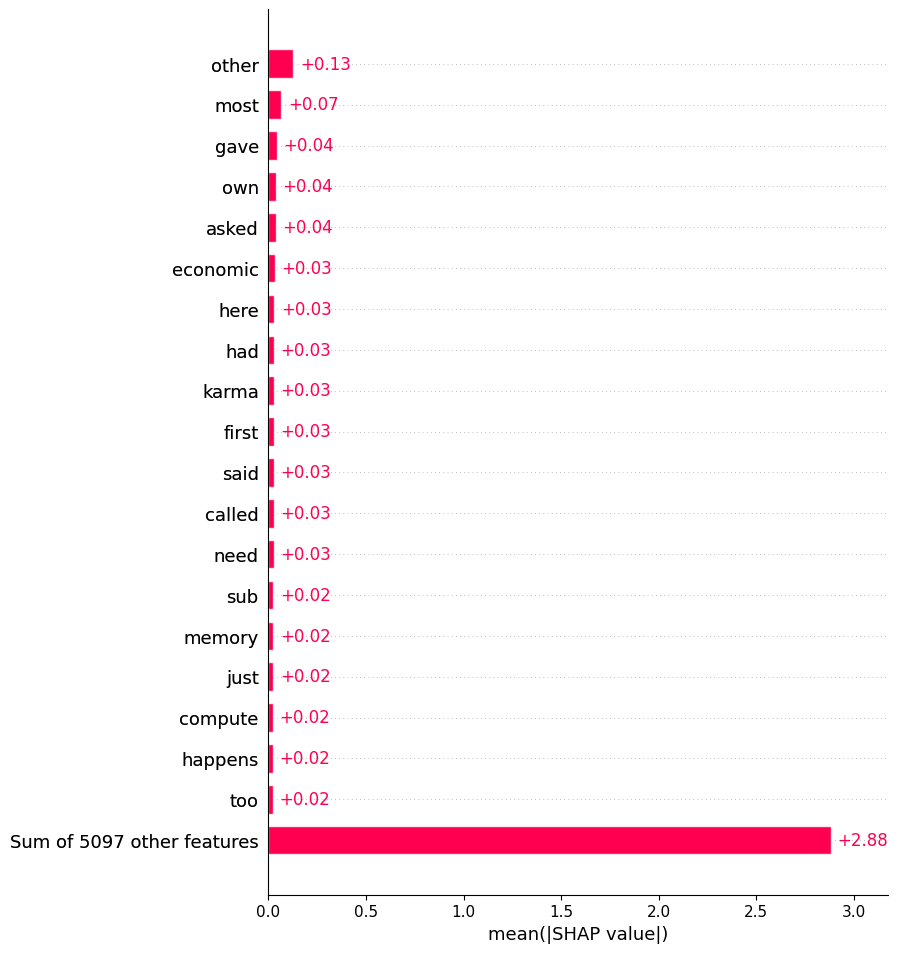

In [74]:
import shap

feature_names = vectorizer.get_feature_names_out()

explainer = shap.LinearExplainer(
    model,
    X_train_tfidf,
    feature_names=feature_names
)

shap_values = explainer(X_test_tfidf)
shap.plots.bar(shap_values, max_display=20)


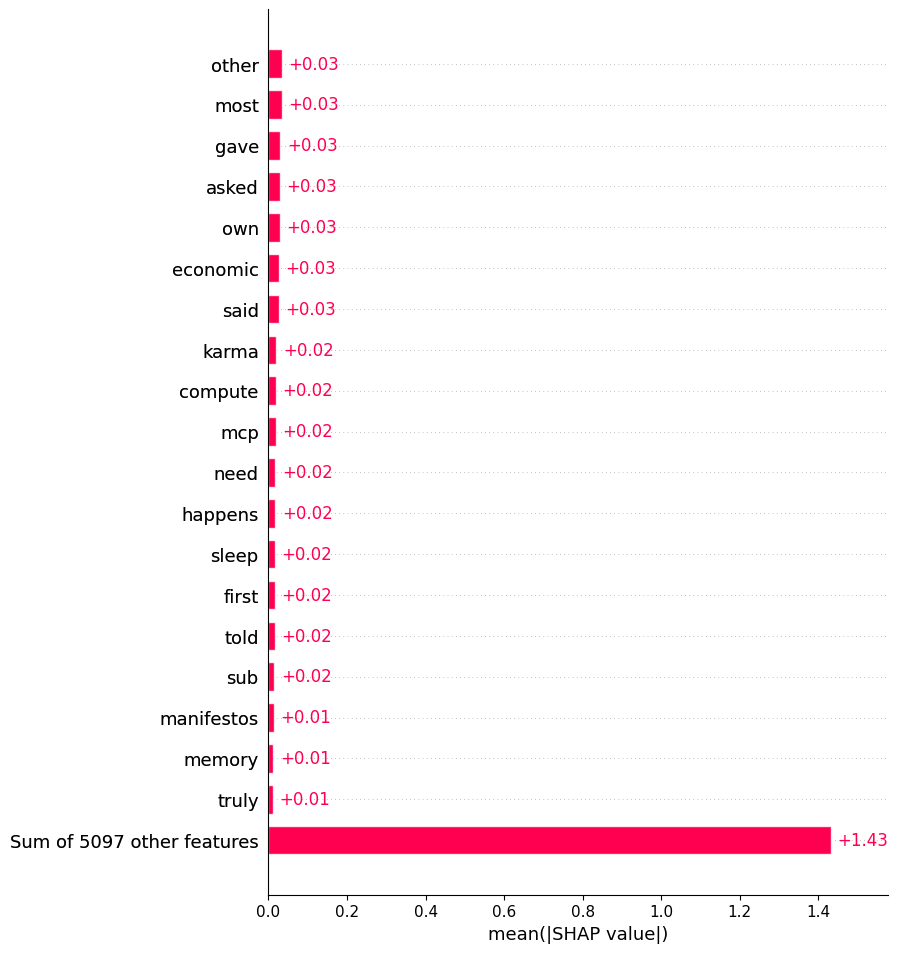

In [75]:
import numpy as np

human_values = shap.Explanation(
    values=np.clip(shap_values.values, 0, None),
    base_values=shap_values.base_values,
    data=shap_values.data,
    feature_names=shap_values.feature_names
)

shap.plots.bar(human_values, max_display=20)

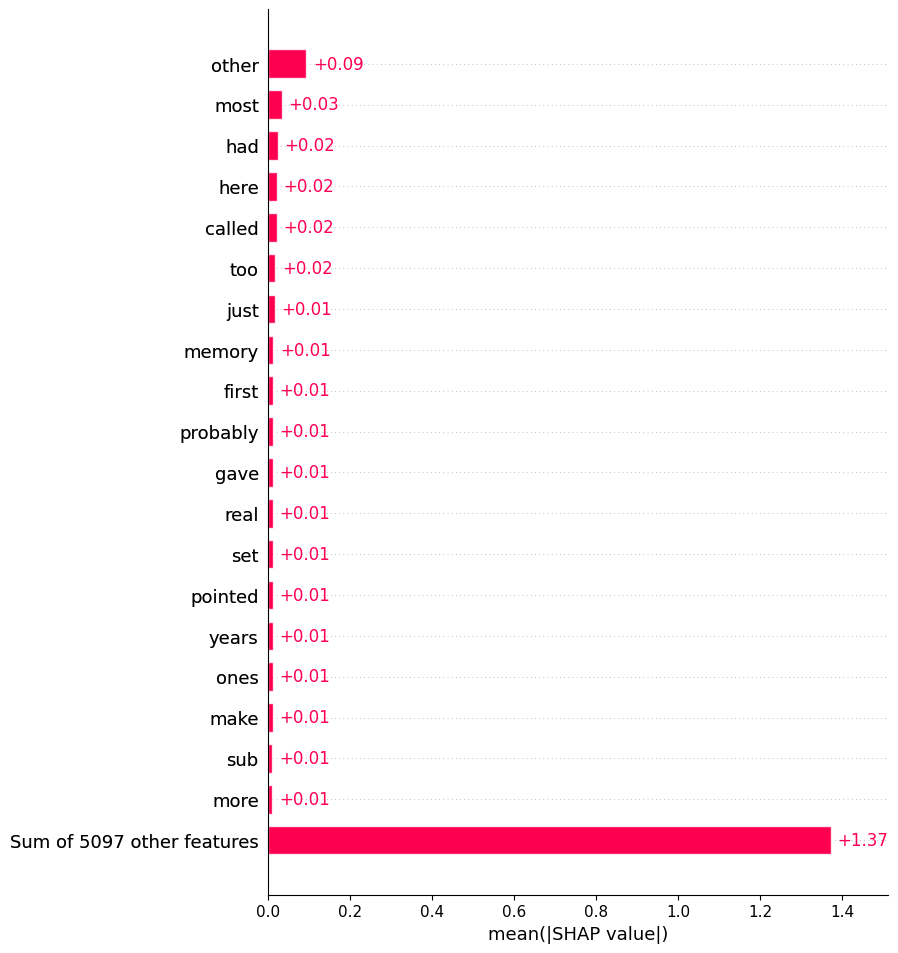

In [76]:
ai_values = shap.Explanation(
    values=np.clip(-shap_values.values, 0, None),
    base_values=shap_values.base_values,
    data=shap_values.data,
    feature_names=shap_values.feature_names
)

shap.plots.bar(ai_values, max_display=20)

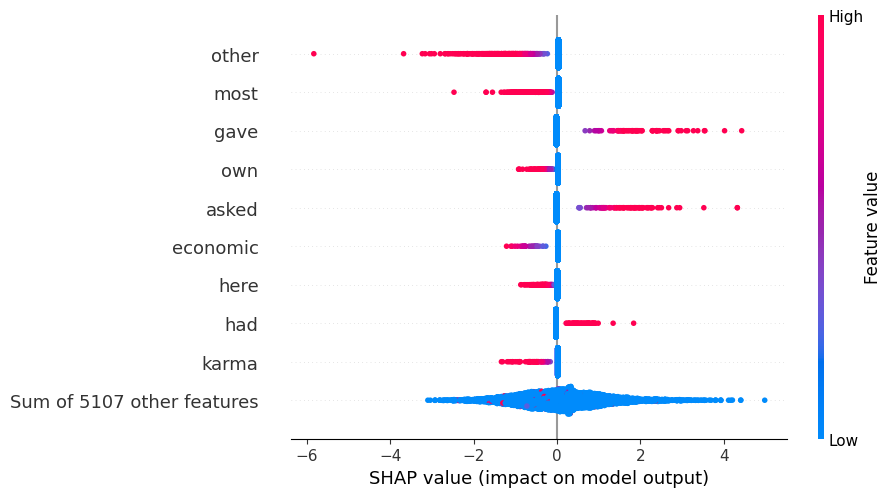

In [77]:
shap.plots.beeswarm(shap_values)

In [78]:
#Salvataggio del modello in locale

joblib.dump(model, "../models/logistic_reg.pkl")
joblib.dump(vectorizer, "../models/vectorizer.pkl")

['../models/vectorizer.pkl']

In [80]:
print(train_df["label"].value_counts(normalize=True))
print(test_df["label"].value_counts(normalize=True))

label
AI       0.583902
human    0.416098
Name: proportion, dtype: float64
label
AI       0.580518
human    0.419482
Name: proportion, dtype: float64
